# MMGTFFF - SEC EDGAR Financial Fundamentals
## Preprocessing Pipeline — Notebook 2
---
**Goal:** Pull 10-K/10-Q financial data from SEC EDGAR for all 87 StockNet tickers.
These become **node-level features** in the graph — the long-term financial health signal.

**What we extract per company per quarter:**
- Revenue, Net Income, Total Assets, Total Liabilities
- Stockholders Equity, Operating Income, EPS, Cash
- Filing date (used for temporal alignment — no look-ahead bias)

**API:** SEC EDGAR XBRL Company Facts (free, no key needed, 10 req/sec limit)

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import requests
import json
import time
import os
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# IMPORTANT: SEC requires a User-Agent header with your name and email.
# Change this to YOUR actual details before running.
HEADERS = {
    'User-Agent': 'MMGTFFF-Research pes1ug23cs031@pesu.pes.edu',
    'Accept-Encoding': 'gzip, deflate'
}

# Load your tickers from the preprocessing output
# Option A: If you saved to Google Drive
# sector_df = pd.read_csv('/content/drive/MyDrive/MMGTFFF/processed_data/sector_mapping.csv')

# Option B: Upload sector_mapping.csv to Colab
# from google.colab import files
# uploaded = files.upload()
# sector_df = pd.read_csv('sector_mapping.csv')

# Option C: Define directly (from our 87 tickers)
TICKERS = [
    'AAPL','ABBV','ABB','ABT','AEP','AGFS','AIG','AMGN','AMZN','AXP',
    'BA','BABA','BAC','BBL','BCH','BHP','BK','BMY','BP','BRK-A',
    'BSAC','BUD','C','CAT','CELG','CHD','CHL','CHTR','CL','CLF',
    'CLX','CMI','CMCSA','CODI','COST','CRM','CSCO','CVS','CVX','D',
    'DE','DHR','DIS','DUK','ED','EL','EMR','ETN','EXC','FB',
    'FCX','GD','GE','GILD','GIS','GMRE','GOLD','GOOG','GS','HD',
    'HON','HRL','HRG','HSBC','HSY','IBM','INTC','IEP','ITW','JNJ',
    'JPM','KO','LLY','LMT','LOW','MA','MCD','MDT','MKC','MMM',
    'MO','MRK','MS','MSFT','NEE','NEM','NFLX','NGG','NUE','NVS',
    'ORCL','PCG','PEP','PFE','PG','PH','PICO','PM','PPL','PTR',
    'QCOM','RDS-B','REX','RIO','RTN','SBUX','SCCO','SJM','SLB','SNP',
    'SNY','SO','SPLP','SRE','T','TEL','TGT','TM','TOT','TSLA',
    'TSM','TXT','UL','UN','UNH','UPS','USB','UTX','V','VALE',
    'VZ','WFC','WMT','XOM'
]

# Remove duplicates and sort
TICKERS = sorted(set(TICKERS))
print(f'Tickers to process: {len(TICKERS)}')

Tickers to process: 134


## 2. Map Tickers → CIK Numbers
SEC EDGAR identifies companies by CIK (Central Index Key), not ticker symbols.

In [3]:
# SEC provides a master ticker→CIK mapping file
url = 'https://www.sec.gov/files/company_tickers.json'
resp = requests.get(url, headers=HEADERS)
ticker_data = resp.json()

# Build lookup: ticker → CIK (zero-padded to 10 digits)
ticker_to_cik = {}
for key, val in ticker_data.items():
    ticker = val['ticker'].upper()
    cik = str(val['cik_str']).zfill(10)
    ticker_to_cik[ticker] = cik

print(f'Total tickers in SEC mapping: {len(ticker_to_cik)}')

# Match our tickers
matched = {}
unmatched = []
for t in TICKERS:
    # Try exact match first, then common alternatives
    lookup = t.replace('-', '.')  # BRK-A → BRK.A etc
    if t in ticker_to_cik:
        matched[t] = ticker_to_cik[t]
    elif lookup in ticker_to_cik:
        matched[t] = ticker_to_cik[lookup]
    elif t == 'GOOG':
        # Google trades as GOOGL on SEC
        matched[t] = ticker_to_cik.get('GOOGL', ticker_to_cik.get('GOOG', ''))
    elif t == 'FB':
        # FB was the ticker in 2014-2015 (before META rebrand)
        matched[t] = ticker_to_cik.get('META', ticker_to_cik.get('FB', ''))
    elif t == 'BRK-A':
        for alt in ['BRK-A', 'BRK.A', 'BRK-B', 'BRK.B']:
            if alt in ticker_to_cik:
                matched[t] = ticker_to_cik[alt]
                break
    else:
        unmatched.append(t)

print(f'\nMatched: {len(matched)}')
print(f'Unmatched: {len(unmatched)}')
if unmatched:
    print(f'Unmatched tickers: {unmatched}')
    print('(These are likely international companies not filing with SEC — expected)')

Total tickers in SEC mapping: 10442

Matched: 119
Unmatched: 15
Unmatched tickers: ['ABB', 'AGFS', 'BBL', 'CELG', 'CHL', 'GMRE', 'HRG', 'PICO', 'PTR', 'RDS-B', 'RTN', 'SNP', 'SPLP', 'TOT', 'UN']
(These are likely international companies not filing with SEC — expected)


## 3. Define Financial Metrics to Extract
SEC XBRL uses standardized taxonomy tags. The same metric can have multiple tag names across companies, so we try several variants.

In [4]:
# XBRL taxonomy tags for each metric (in priority order)
# We try each tag until one returns data for a given company

METRIC_TAGS = {
    'Revenue': [
        'RevenueFromContractWithCustomerExcludingAssessedTax',
        'Revenues',
        'SalesRevenueNet',
        'SalesRevenueGoodsNet',
        'RevenueFromContractWithCustomerIncludingAssessedTax',
    ],
    'NetIncome': [
        'NetIncomeLoss',
        'NetIncomeLossAvailableToCommonStockholdersBasic',
        'ProfitLoss',
    ],
    'TotalAssets': [
        'Assets',
    ],
    'TotalLiabilities': [
        'Liabilities',
        'LiabilitiesAndStockholdersEquity',
    ],
    'StockholdersEquity': [
        'StockholdersEquity',
        'StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest',
    ],
    'OperatingIncome': [
        'OperatingIncomeLoss',
    ],
    'EPS': [
        'EarningsPerShareBasic',
        'EarningsPerShareDiluted',
    ],
    'Cash': [
        'CashAndCashEquivalentsAtCarryingValue',
        'CashCashEquivalentsAndShortTermInvestments',
    ],
}

print(f'Metrics to extract: {list(METRIC_TAGS.keys())}')

Metrics to extract: ['Revenue', 'NetIncome', 'TotalAssets', 'TotalLiabilities', 'StockholdersEquity', 'OperatingIncome', 'EPS', 'Cash']


## 4. Pull Data from EDGAR API

In [5]:
def get_company_facts(cik):
    """Fetch all XBRL facts for a company from SEC EDGAR."""
    url = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
    resp = requests.get(url, headers=HEADERS)
    if resp.status_code == 200:
        return resp.json()
    return None

def extract_metric(facts_data, tag_variants, start_date='2013-01-01', end_date='2016-06-30'):
    """
    Extract a financial metric from EDGAR facts data.
    Tries multiple XBRL tag variants.
    Returns list of {filed, end, val, form} dicts.
    """
    if not facts_data or 'facts' not in facts_data:
        return []

    us_gaap = facts_data['facts'].get('us-gaap', {})

    for tag in tag_variants:
        if tag not in us_gaap:
            continue

        units = us_gaap[tag].get('units', {})
        # Financial values are in USD or USD/shares (for EPS)
        values = units.get('USD', units.get('USD/shares', []))

        if not values:
            continue

        results = []
        for entry in values:
            filed = entry.get('filed', '')
            end = entry.get('end', '')
            form = entry.get('form', '')
            val = entry.get('val')

            # Only 10-K (annual) and 10-Q (quarterly) filings
            if form not in ['10-K', '10-Q', '10-K/A', '10-Q/A', '20-F']:
                continue

            # Filter to our date window (with buffer for look-back)
            if filed < start_date or filed > end_date:
                continue

            if val is not None:
                results.append({
                    'filed': filed,
                    'period_end': end,
                    'value': val,
                    'form': form
                })

        if results:
            return results

    return []

# Test with AAPL
print('Testing with AAPL...')
aapl_cik = matched['AAPL']
aapl_facts = get_company_facts(aapl_cik)
print(f'AAPL CIK: {aapl_cik}')
print(f'Facts loaded: {aapl_facts is not None}')

# Try extracting revenue
rev = extract_metric(aapl_facts, METRIC_TAGS['Revenue'])
print(f'Revenue entries: {len(rev)}')
if rev:
    for r in rev[:3]:
        print(f"  Filed: {r['filed']}, Period: {r['period_end']}, "
              f"Value: ${r['value']:,.0f}, Form: {r['form']}")

Testing with AAPL...
AAPL CIK: 0000320193
Facts loaded: True
Revenue entries: 69
  Filed: 2013-10-30, Period: 2011-09-24, Value: $108,249,000,000, Form: 10-K
  Filed: 2013-01-24, Period: 2011-12-31, Value: $46,333,000,000, Form: 10-Q
  Filed: 2013-10-30, Period: 2011-12-31, Value: $46,333,000,000, Form: 10-K


In [6]:
# Pull data for ALL matched tickers
# SEC rate limit: 10 req/sec — we add a small delay

all_fundamentals = []
failed_tickers = []
no_data_tickers = []

for ticker, cik in tqdm(matched.items(), desc='Fetching from EDGAR'):
    try:
        facts = get_company_facts(cik)
        if facts is None:
            failed_tickers.append(ticker)
            time.sleep(0.15)
            continue

        ticker_has_data = False

        for metric_name, tag_variants in METRIC_TAGS.items():
            entries = extract_metric(facts, tag_variants)
            for entry in entries:
                all_fundamentals.append({
                    'Ticker': ticker,
                    'Metric': metric_name,
                    'Filed_Date': entry['filed'],
                    'Period_End': entry['period_end'],
                    'Value': entry['value'],
                    'Form': entry['form']
                })
                ticker_has_data = True

        if not ticker_has_data:
            no_data_tickers.append(ticker)

        # Rate limiting — stay well under 10 req/sec
        time.sleep(0.15)

    except Exception as e:
        failed_tickers.append((ticker, str(e)))
        time.sleep(0.15)

fund_df = pd.DataFrame(all_fundamentals)
print(f'\n{"="*50}')
print(f'EDGAR Fetch Results')
print(f'{"="*50}')
print(f'Total records: {len(fund_df)}')
print(f'Tickers with data: {fund_df["Ticker"].nunique()}')
print(f'Failed API calls: {len(failed_tickers)}')
print(f'No data found: {len(no_data_tickers)}')
if failed_tickers:
    print(f'Failed: {failed_tickers}')
if no_data_tickers:
    print(f'No data: {no_data_tickers}')

Fetching from EDGAR:   0%|          | 0/119 [00:00<?, ?it/s]


EDGAR Fetch Results
Total records: 35807
Tickers with data: 105
Failed API calls: 1
No data found: 13
Failed: ['UTX']
No data: ['BCH', 'BHP', 'BP', 'BSAC', 'BUD', 'DIS', 'HSBC', 'NGG', 'NVS', 'RIO', 'SNY', 'TSM', 'UL']


In [7]:
# Quick look at what we got
print('=== Records per metric ===')
print(fund_df.groupby('Metric').size().to_string())
print(f'\n=== Records per form type ===')
print(fund_df.groupby('Form').size().to_string())
print(f'\n=== Date range ===')
print(f'Filed: {fund_df["Filed_Date"].min()} to {fund_df["Filed_Date"].max()}')
print(f'\n=== Sample (AAPL) ===')
print(fund_df[fund_df['Ticker']=='AAPL'].head(10).to_string())

=== Records per metric ===
Metric
Cash                  5261
EPS                   5900
NetIncome             6181
OperatingIncome       3984
Revenue               5356
StockholdersEquity    3155
TotalAssets           3142
TotalLiabilities      2828

=== Records per form type ===
Form
10-K      14488
10-K/A       97
10-Q      21129
10-Q/A       47
20-F         46

=== Date range ===
Filed: 2013-01-24 to 2016-06-30

=== Sample (AAPL) ===
  Ticker   Metric  Filed_Date  Period_End         Value  Form
0   AAPL  Revenue  2013-10-30  2011-09-24  1.082490e+11  10-K
1   AAPL  Revenue  2013-01-24  2011-12-31  4.633300e+10  10-Q
2   AAPL  Revenue  2013-10-30  2011-12-31  4.633300e+10  10-K
3   AAPL  Revenue  2013-04-24  2012-03-31  8.551900e+10  10-Q
4   AAPL  Revenue  2013-04-24  2012-03-31  3.918600e+10  10-Q
5   AAPL  Revenue  2013-10-30  2012-03-31  3.918600e+10  10-K
6   AAPL  Revenue  2013-07-24  2012-06-30  1.205420e+11  10-Q
7   AAPL  Revenue  2013-07-24  2012-06-30  3.502300e+10  10-Q
8

## 5. Pivot to Wide Format
Convert from long format (one row per metric per filing) to wide format (one row per company per filing period) with columns for each metric.

In [8]:
# Deduplicate: if same metric appears multiple times for same ticker+period,
# keep the one from the latest filing (amendments override originals)
fund_df['Filed_Date'] = pd.to_datetime(fund_df['Filed_Date'])
fund_df['Period_End'] = pd.to_datetime(fund_df['Period_End'])

fund_dedup = (
    fund_df
    .sort_values('Filed_Date')
    .drop_duplicates(subset=['Ticker', 'Metric', 'Period_End'], keep='last')
)
print(f'Before dedup: {len(fund_df)}, After: {len(fund_dedup)}')

# Pivot to wide format
fund_wide = fund_dedup.pivot_table(
    index=['Ticker', 'Period_End', 'Filed_Date', 'Form'],
    columns='Metric',
    values='Value',
    aggfunc='first'
).reset_index()

# Flatten column names
fund_wide.columns.name = None

print(f'\nWide format shape: {fund_wide.shape}')
print(f'Columns: {list(fund_wide.columns)}')
print(f'Tickers: {fund_wide["Ticker"].nunique()}')
print(f'\nSample:')
fund_wide[fund_wide['Ticker']=='AAPL'].head()

Before dedup: 35807, After: 13665

Wide format shape: (4471, 12)
Columns: ['Ticker', 'Period_End', 'Filed_Date', 'Form', 'Cash', 'EPS', 'NetIncome', 'OperatingIncome', 'Revenue', 'StockholdersEquity', 'TotalAssets', 'TotalLiabilities']
Tickers: 105

Sample:


,Ticker,Period_End,Filed_Date,Form,Cash,EPS,NetIncome,OperatingIncome,Revenue,StockholdersEquity,TotalAssets,TotalLiabilities
0,AAPL,2010-09-25,2013-10-30,10-K,1.126100e+10,NaN,NaN,NaN,NaN,4.779100e+10,NaN,NaN
1,AAPL,2011-09-24,2013-10-30,10-K,NaN,28.05,2.592200e+10,3.379000e+10,1.082490e+11,NaN,NaN,NaN
2,AAPL,2011-09-24,2014-10-27,10-K,9.815000e+09,NaN,NaN,NaN,NaN,7.661500e+10,NaN,NaN
3,AAPL,2011-12-31,2013-01-24,10-Q,1.031000e+10,NaN,NaN,1.734000e+10,NaN,NaN,NaN,NaN
4,AAPL,2011-12-31,2013-10-30,10-K,NaN,14.03,1.306400e+10,NaN,4.633300e+10,NaN,NaN,NaN


## 6. Compute Derived Ratios
These ratios are more informative as node features than raw dollar amounts, since they're scale-invariant across companies.

In [9]:
# Derived ratios
fund_wide['Profit_Margin'] = fund_wide['NetIncome'] / fund_wide['Revenue']
fund_wide['Debt_To_Equity'] = fund_wide['TotalLiabilities'] / fund_wide['StockholdersEquity']
fund_wide['ROA'] = fund_wide['NetIncome'] / fund_wide['TotalAssets']
fund_wide['Current_Ratio'] = fund_wide['Cash'] / fund_wide['TotalLiabilities']
fund_wide['Asset_Turnover'] = fund_wide['Revenue'] / fund_wide['TotalAssets']
fund_wide['Operating_Margin'] = fund_wide['OperatingIncome'] / fund_wide['Revenue']

# Replace inf/-inf with NaN
fund_wide = fund_wide.replace([np.inf, -np.inf], np.nan)

print('Derived ratios added.')
print(f'Shape: {fund_wide.shape}')
print(f'\nRatio coverage (non-null %):')
ratio_cols = ['Profit_Margin','Debt_To_Equity','ROA','Current_Ratio','Asset_Turnover','Operating_Margin']
for col in ratio_cols:
    pct = fund_wide[col].notna().mean() * 100
    print(f'  {col}: {pct:.1f}%')

Derived ratios added.
Shape: (4471, 18)

Ratio coverage (non-null %):
  Profit_Margin: 33.1%
  Debt_To_Equity: 29.2%
  ROA: 10.9%
  Current_Ratio: 9.8%
  Asset_Turnover: 10.8%
  Operating_Margin: 21.8%


## 7. Temporal Alignment with Price Data
Critical for avoiding look-ahead bias: a filing's financial data should only be available to the model **after** the filing date, not the period end date.

We forward-fill each company's fundamentals from their filing date until the next filing arrives.

In [11]:
# Load the price features from notebook 1
# Adjust path depending on where you saved it
price_df = pd.read_csv('processed_data/stocknet_price_features.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])
print(f'Price data: {price_df.shape}')
print(f'Date range: {price_df["Date"].min()} to {price_df["Date"].max()}')

Price data: (26603, 29)
Date range: 2014-01-02 00:00:00 to 2015-12-31 00:00:00


In [20]:
# ============================================================
# FIXED ALIGNMENT: Forward-fill each metric independently
# from raw long-format data. Avoids the pivot dedup problem.
# ============================================================

fundamental_cols = [
    'Revenue', 'NetIncome', 'TotalAssets', 'TotalLiabilities',
    'StockholdersEquity', 'OperatingIncome', 'EPS', 'Cash',
]

ratio_definitions = {
    'Profit_Margin': ('NetIncome', 'Revenue'),
    'Debt_To_Equity': ('TotalLiabilities', 'StockholdersEquity'),
    'ROA': ('NetIncome', 'TotalAssets'),
    'Current_Ratio': ('Cash', 'TotalLiabilities'),
    'Asset_Turnover': ('Revenue', 'TotalAssets'),
    'Operating_Margin': ('OperatingIncome', 'Revenue'),
}

all_fundamental_cols = fundamental_cols + list(ratio_definitions.keys())

# Load price data
price_df = pd.read_csv('processed_data/stocknet_price_features.csv')
price_df['Date'] = pd.to_datetime(price_df['Date'])
print(f'Price data: {price_df.shape}')

# Use the RAW long-format EDGAR data, not the wide pivot
fund_df['Filed_Date'] = pd.to_datetime(fund_df['Filed_Date'])

def align_ticker_fundamentals(ticker, fund_raw, daily_dates):
    """Forward-fill each metric independently from raw EDGAR data."""
    result = pd.DataFrame({'Date': daily_dates})
    daily_index = pd.DatetimeIndex(daily_dates)

    ticker_data = fund_raw[fund_raw['Ticker'] == ticker]

    if len(ticker_data) == 0:
        for col in all_fundamental_cols:
            result[col] = np.nan
        result['Ticker'] = ticker
        return result

    # For each metric, build a time series and forward-fill
    for metric in fundamental_cols:
        metric_data = (
            ticker_data[ticker_data['Metric'] == metric]
            .sort_values('Filed_Date')
            .drop_duplicates(subset=['Filed_Date'], keep='last')
        )

        if len(metric_data) == 0:
            result[metric] = np.nan
            continue

        # Create series indexed by filing date
        ts = metric_data.set_index('Filed_Date')['Value']
        # Remove duplicate index entries (safety)
        ts = ts[~ts.index.duplicated(keep='last')]
        # Reindex to daily and forward-fill
        ts_daily = ts.reindex(daily_index, method='ffill')
        result[metric] = ts_daily.values

    # Compute ratios from the forward-filled daily values
    for ratio_name, (numerator, denominator) in ratio_definitions.items():
        if numerator in result.columns and denominator in result.columns:
            result[ratio_name] = result[numerator] / result[denominator]
        else:
            result[ratio_name] = np.nan

    # Clean inf
    result = result.replace([np.inf, -np.inf], np.nan)
    result['Ticker'] = ticker
    return result

# Process all tickers
aligned_dfs = []
tickers_in_price = price_df['Ticker'].unique()

for ticker in tqdm(tickers_in_price, desc='Aligning fundamentals'):
    daily_dates = price_df[price_df['Ticker'] == ticker]['Date'].values
    aligned = align_ticker_fundamentals(ticker, fund_df, daily_dates)
    aligned_dfs.append(aligned)

fund_aligned = pd.concat(aligned_dfs, ignore_index=True)

# Check coverage
print(f'\nAligned shape: {fund_aligned.shape}')
print(f'Tickers: {fund_aligned["Ticker"].nunique()}')
print(f'\nCoverage:')
for col in all_fundamental_cols:
    n = fund_aligned[col].notna().sum()
    pct = 100 * n / len(fund_aligned)
    tickers_with = fund_aligned[fund_aligned[col].notna()]['Ticker'].nunique()
    print(f'  {col}: {n} rows ({pct:.1f}%), {tickers_with} tickers')

Price data: (26603, 29)


Aligning fundamentals:   0%|          | 0/87 [00:00<?, ?it/s]


Aligned shape: (26603, 16)
Tickers: 87

Coverage:
  Revenue: 16794 rows (63.1%), 59 tickers
  NetIncome: 17410 rows (65.4%), 60 tickers
  TotalAssets: 17410 rows (65.4%), 60 tickers
  TotalLiabilities: 17114 rows (64.3%), 58 tickers
  StockholdersEquity: 17410 rows (65.4%), 60 tickers
  OperatingIncome: 13273 rows (49.9%), 47 tickers
  EPS: 16672 rows (62.7%), 58 tickers
  Cash: 16183 rows (60.8%), 56 tickers
  Profit_Margin: 16746 rows (62.9%), 59 tickers
  Debt_To_Equity: 17114 rows (64.3%), 58 tickers
  ROA: 17410 rows (65.4%), 60 tickers
  Current_Ratio: 15887 rows (59.7%), 54 tickers
  Asset_Turnover: 16794 rows (63.1%), 59 tickers
  Operating_Margin: 12947 rows (48.7%), 47 tickers


In [19]:
# ============================================================
# DIAGNOSTIC: Where are the 55 missing tickers getting lost?
# ============================================================

print("="*60)
print("STAGE 1: CIK Matching")
print("="*60)
tickers_in_price = set(price_df['Ticker'].unique())
tickers_matched_cik = set(matched.keys())
no_cik = tickers_in_price - tickers_matched_cik
print(f"Price tickers: {len(tickers_in_price)}")
print(f"Matched to CIK: {len(tickers_matched_cik & tickers_in_price)}")
print(f"No CIK match: {len(no_cik)}")
if no_cik:
    print(f"  → {sorted(no_cik)}")

print(f"\n{'='*60}")
print("STAGE 2: EDGAR API returned data")
print("="*60)
tickers_in_raw = set(fund_df['Ticker'].unique())
had_cik_but_no_data = (tickers_matched_cik & tickers_in_price) - tickers_in_raw
print(f"Tickers in raw EDGAR data: {len(tickers_in_raw)}")
print(f"Had CIK but no EDGAR data: {len(had_cik_but_no_data)}")
if had_cik_but_no_data:
    print(f"  → {sorted(had_cik_but_no_data)}")

print(f"\n{'='*60}")
print("STAGE 3: Wide format (after pivot)")
print("="*60)
tickers_in_wide = set(fund_wide['Ticker'].unique())
in_raw_not_wide = (tickers_in_raw & tickers_in_price) - tickers_in_wide
print(f"Tickers in wide format: {len(tickers_in_wide)}")
print(f"In raw but not wide: {len(in_raw_not_wide)}")
if in_raw_not_wide:
    print(f"  → {sorted(in_raw_not_wide)}")

print(f"\n{'='*60}")
print("STAGE 4: Ticker name mismatch (the likely culprit)")
print("="*60)
# Check: are tickers in fund_wide that DON'T match price_df tickers?
in_wide_not_price = tickers_in_wide - tickers_in_price
in_price_not_wide = tickers_in_price - tickers_in_wide
print(f"In EDGAR wide but NOT in price data: {len(in_wide_not_price)}")
if in_wide_not_price:
    print(f"  → {sorted(in_wide_not_price)}")
print(f"In price data but NOT in EDGAR wide: {len(in_price_not_wide)}")
if in_price_not_wide:
    print(f"  → {sorted(in_price_not_wide)}")

print(f"\n{'='*60}")
print("STAGE 5: Revenue specifically")
print("="*60)
has_revenue = set(fund_wide[fund_wide['Revenue'].notna()]['Ticker'].unique())
has_assets = set(fund_wide[fund_wide['TotalAssets'].notna()]['Ticker'].unique())
print(f"Tickers with Revenue in wide: {len(has_revenue)}")
print(f"Tickers with TotalAssets in wide: {len(has_assets)}")
print(f"Have Assets but NOT Revenue: {sorted(has_assets - has_revenue)}")

# For a known missing US company, check what happened
for test_ticker in ['AMZN', 'WMT', 'DIS', 'BA', 'XOM']:
    print(f"\n--- Debug {test_ticker} ---")
    if test_ticker in matched:
        print(f"  CIK: {matched[test_ticker]}")
        raw_rows = fund_df[fund_df['Ticker']==test_ticker]
        print(f"  Raw EDGAR rows: {len(raw_rows)}")
        if len(raw_rows) > 0:
            print(f"  Metrics found: {raw_rows['Metric'].unique().tolist()}")
            print(f"  Filed dates: {raw_rows['Filed_Date'].min()} to {raw_rows['Filed_Date'].max()}")
        wide_rows = fund_wide[fund_wide['Ticker']==test_ticker]
        print(f"  Wide format rows: {len(wide_rows)}")
        if len(wide_rows) > 0:
            print(f"  Revenue non-null: {wide_rows['Revenue'].notna().sum()}")
    else:
        print(f"  NOT in CIK matched dict!")
        # Check if it's in raw under a different name
        possible = fund_df[fund_df['Ticker'].str.contains(test_ticker[:3], case=False)]
        if len(possible) > 0:
            print(f"  Possible matches in raw: {possible['Ticker'].unique().tolist()}")

STAGE 1: CIK Matching
Price tickers: 87
Matched to CIK: 73
No CIK match: 14
  → ['ABB', 'AGFS', 'BBL', 'CELG', 'CHL', 'HRG', 'PCLN', 'PICO', 'PTR', 'RDS-B', 'SNP', 'SPLP', 'TOT', 'UN']

STAGE 2: EDGAR API returned data
Tickers in raw EDGAR data: 105
Had CIK but no EDGAR data: 13
  → ['BCH', 'BHP', 'BP', 'BSAC', 'BUD', 'DIS', 'HSBC', 'NGG', 'NVS', 'SNY', 'TSM', 'UL', 'UTX']

STAGE 3: Wide format (after pivot)
Tickers in wide format: 105
In raw but not wide: 0

STAGE 4: Ticker name mismatch (the likely culprit)
In EDGAR wide but NOT in price data: 45
  → ['ABT', 'AIG', 'AXP', 'BK', 'BMY', 'CHD', 'CL', 'CLF', 'CLX', 'CMI', 'COST', 'CRM', 'CVS', 'DE', 'ED', 'EL', 'EMR', 'ETN', 'FCX', 'GILD', 'GIS', 'GOLD', 'GS', 'HRL', 'HSY', 'IBM', 'ITW', 'LLY', 'LOW', 'MKC', 'MS', 'NEM', 'NFLX', 'NUE', 'PH', 'QCOM', 'SBUX', 'SCCO', 'SJM', 'TEL', 'TGT', 'TSLA', 'TXT', 'USB', 'VALE']
In price data but NOT in EDGAR wide: 27
  → ['ABB', 'AGFS', 'BBL', 'BCH', 'BHP', 'BP', 'BSAC', 'BUD', 'CELG', 'CHL', 'DIS', 

## 8. Merge with Price Data

In [21]:
# Merge fundamentals onto the price dataframe
final_df = price_df.merge(
    fund_aligned,
    on=['Ticker', 'Date'],
    how='left'
)

print(f'Final merged shape: {final_df.shape}')
print(f'\nNew columns added: {fundamental_cols}')
print(f'\nCoverage in final dataset:')
for col in fundamental_cols:
    pct = final_df[col].notna().mean() * 100
    print(f'  {col}: {pct:.1f}%')

print(f'\nSample (AAPL):')
aapl = final_df[final_df['Ticker']=='AAPL'][['Date','Close','Return','Target',
    'Revenue','NetIncome','TotalAssets','Profit_Margin','ROA','EPS']]
print(aapl.iloc[::50].to_string())  # every 50th row

Final merged shape: (26603, 43)

New columns added: ['Revenue', 'NetIncome', 'TotalAssets', 'TotalLiabilities', 'StockholdersEquity', 'OperatingIncome', 'EPS', 'Cash']

Coverage in final dataset:
  Revenue: 63.1%
  NetIncome: 65.4%
  TotalAssets: 65.4%
  TotalLiabilities: 64.3%
  StockholdersEquity: 65.4%
  OperatingIncome: 49.9%
  EPS: 62.7%
  Cash: 60.8%

Sample (AAPL):
          Date       Close    Return  Target       Revenue     NetIncome   TotalAssets  Profit_Margin       ROA    EPS
0   2014-01-02   79.018570 -0.014064       0  3.596600e+10  8.223000e+09  2.070000e+11       0.228633  0.039725   8.76
50  2014-04-25   81.705711  0.007344       1  1.032400e+11  2.329500e+10  2.070000e+11       0.225639  0.112536  26.31
100 2014-09-03   98.940002 -0.042207       0  1.334380e+11  2.952500e+10  2.070000e+11       0.221264  0.142633   4.52
150 2014-12-18  112.650002  0.029613       1  3.532300e+10  6.900000e+09  2.318390e+11       0.195340  0.029762   1.07
200 2015-03-26  124.239998  0.

## 9. Save

In [22]:
os.makedirs('processed_data_secedgar', exist_ok=True)

# 1. Raw EDGAR data (long format — for reference)
fund_df.to_csv('processed_data_secedgar/edgar_raw_fundamentals.csv', index=False)
print(f'edgar_raw_fundamentals.csv: {fund_df.shape}')

# 2. Wide format with ratios (per filing period)
fund_wide.to_csv('processed_data_secedgar/edgar_fundamentals_wide.csv', index=False)
print(f'edgar_fundamentals_wide.csv: {fund_wide.shape}')

# 3. Daily-aligned fundamentals (ready to merge with anything)
fund_aligned.to_parquet('processed_data_secedgar/edgar_daily_aligned.parquet', index=False)
print(f'edgar_daily_aligned.parquet: {fund_aligned.shape}')

# 4. Final merged dataset (price + tweets + fundamentals)
final_df.to_csv('processed_data_secedgar/stocknet_with_fundamentals.csv', index=False)
print(f'stocknet_with_fundamentals.csv: {final_df.shape}')

print('\n=== All files ===')
!ls -lh processed_data/

edgar_raw_fundamentals.csv: (35807, 6)
edgar_fundamentals_wide.csv: (4471, 18)
edgar_daily_aligned.parquet: (26603, 16)
stocknet_with_fundamentals.csv: (26603, 43)

=== All files ===
total 39M
-rw-r--r-- 1 root root 2.5M Mar 21 12:38  company_tweets.parquet
-rw-r--r-- 1 root root 172K Mar 21 12:38 'eda_v2 (1).png'
-rw-r--r-- 1 root root 172K Mar 21 12:38  eda_v2.png
-rw-r--r-- 1 root root  70K Mar 21 12:41  edgar_daily_aligned.parquet
-rw-r--r-- 1 root root 139K Mar 21 12:42  edgar_eda.png
-rw-r--r-- 1 root root 439K Mar 21 12:41  edgar_fundamentals_wide.csv
-rw-r--r-- 1 root root 1.9M Mar 21 12:41  edgar_raw_fundamentals.csv
-rw-r--r-- 1 root root 290K Mar 21 12:38  event_tweets.parquet
-rw-r--r-- 1 root root 1.5K Mar 21 12:38  sector_mapping.csv
-rw-r--r-- 1 root root  12M Mar 21 12:39  stocknet_full.parquet
-rw-r--r-- 1 root root 9.9M Mar 21 12:39  stocknet_price_features.csv
-rw-r--r-- 1 root root  12M Mar 21 12:42  stocknet_with_fundamentals.csv


In [23]:
# VALIDATION
print('=== VALIDATION ===')
v = pd.read_csv('processed_data_secedgar/stocknet_with_fundamentals.csv')
print(f'Shape: {v.shape}')
print(f'Tickers: {v["Ticker"].nunique()}')
print(f'Has Revenue data: {v["Revenue"].notna().sum()} rows')
print(f'Has NetIncome data: {v["NetIncome"].notna().sum()} rows')
print(f'Has EPS data: {v["EPS"].notna().sum()} rows')
print(f'\nTickers WITH fundamentals: {v[v["Revenue"].notna()]["Ticker"].nunique()}')
print(f'Tickers WITHOUT any fundamentals: {v[v["Revenue"].isna()]["Ticker"].nunique()}')

# List tickers missing fundamentals
all_t = set(v['Ticker'].unique())
has_fund = set(v[v['Revenue'].notna()]['Ticker'].unique())
missing = all_t - has_fund
if missing:
    print(f'Missing: {sorted(missing)}')
    print('(Likely international companies without SEC filings — expected)')

=== VALIDATION ===
Shape: (26603, 43)
Tickers: 87
Has Revenue data: 16794 rows
Has NetIncome data: 17410 rows
Has EPS data: 16672 rows

Tickers WITH fundamentals: 59
Tickers WITHOUT any fundamentals: 33
Missing: ['ABB', 'AGFS', 'BBL', 'BCH', 'BHP', 'BP', 'BSAC', 'BUD', 'CELG', 'CHL', 'DIS', 'HRG', 'HSBC', 'NGG', 'NVS', 'PCLN', 'PICO', 'PTR', 'RDS-B', 'SNP', 'SNY', 'SPLP', 'TOT', 'TSM', 'UL', 'UN', 'UTX', 'WFC']
(Likely international companies without SEC filings — expected)


## 10. Quick EDA

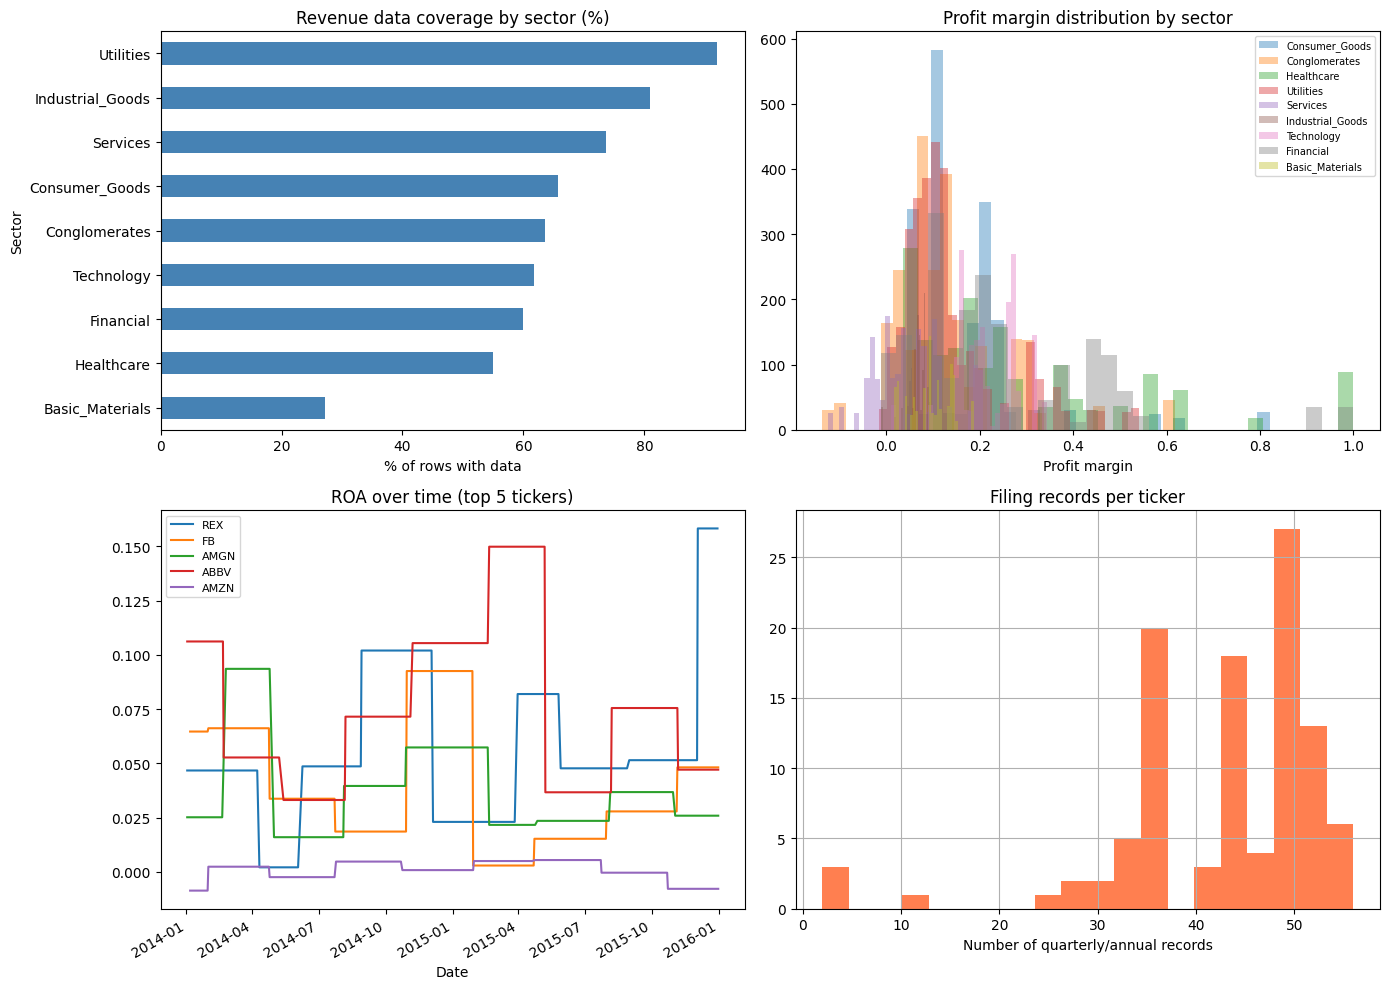

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fundamental coverage by sector
coverage = final_df.groupby('Sector')['Revenue'].apply(
    lambda x: x.notna().mean() * 100
).sort_values()
coverage.plot.barh(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Revenue data coverage by sector (%)')
axes[0,0].set_xlabel('% of rows with data')

# 2. Profit margin distribution by sector
for sector in final_df['Sector'].unique():
    data = final_df[final_df['Sector']==sector]['Profit_Margin'].dropna()
    if len(data) > 0:
        axes[0,1].hist(data.clip(-1, 1), bins=30, alpha=0.4, label=sector)
axes[0,1].set_title('Profit margin distribution by sector')
axes[0,1].set_xlabel('Profit margin')
axes[0,1].legend(fontsize=7)

# 3. ROA over time (top 5 tickers by data availability)
top_tickers = final_df[final_df['ROA'].notna()].groupby('Ticker').size().nlargest(5).index
for t in top_tickers:
    sub = final_df[final_df['Ticker']==t].set_index('Date')['ROA'].dropna()
    sub.plot(ax=axes[1,0], label=t)
axes[1,0].set_title('ROA over time (top 5 tickers)')
axes[1,0].legend(fontsize=8)

# 4. Metrics per ticker count
metrics_per_ticker = fund_wide.groupby('Ticker').size()
metrics_per_ticker.hist(bins=20, ax=axes[1,1], color='coral')
axes[1,1].set_title('Filing records per ticker')
axes[1,1].set_xlabel('Number of quarterly/annual records')

plt.tight_layout()
plt.savefig('processed_data_secedgar/edgar_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Optional: Save to Google Drive
# !cp -r processed_data/ /content/drive/MyDrive/MMGTFFF/processed_data/

## Summary

### What was added:
- 8 financial metrics per company per filing period (Revenue, NetIncome, TotalAssets, TotalLiabilities, StockholdersEquity, OperatingIncome, EPS, Cash)
- 6 derived ratios (Profit_Margin, Debt_To_Equity, ROA, Current_Ratio, Asset_Turnover, Operating_Margin)
- Temporally aligned to daily dates using filing date (no look-ahead bias)
- Forward-filled between filing dates

### How these fit the architecture:
- **Raw metrics** (Revenue, Assets, etc.) → node features, scale per company
- **Ratios** (ROA, Profit_Margin, etc.) → cross-company comparable node features
- **Filing dates** → event triggers (a new filing = potential graph edge update)
- International tickers without SEC filings get NaN → will be imputed or handled by the model

### Output files:
| File | Contents | Use |
|------|----------|-----|
| `edgar_raw_fundamentals.csv` | Long format, all records | Reference |
| `edgar_fundamentals_wide.csv` | Wide format per filing | Analysis |
| `edgar_daily_aligned.parquet` | Daily aligned, forward-filled | Merge with any daily data |
| `stocknet_with_fundamentals.csv` | Price + tweets + fundamentals | Ready for modeling |

### Next steps:
1. FinBERT encoding (company + event tweet embeddings)
2. Graph construction (sector edges + correlation edges + event edges)
3. Federated client partitioning
4. Baseline models

In [27]:
import pandas as pd
import os

# Load all pieces
main_df = pd.read_csv('processed_data_secedgar/stocknet_with_fundamentals.csv')
comp_tweets = pd.read_parquet('processed_data/company_tweets.parquet')
evt_tweets = pd.read_parquet('processed_data/event_tweets.parquet')

print(f"Main: {main_df.shape}")
print(f"Company tweets: {comp_tweets.shape}")
print(f"Event tweets: {evt_tweets.shape}")

# Merge tweet texts onto main dataframe
main_df['Date'] = pd.to_datetime(main_df['Date'])
comp_tweets['Date'] = pd.to_datetime(comp_tweets['Date'])
evt_tweets['Date'] = pd.to_datetime(evt_tweets['Date'])

# Add company tweet texts
final_df = main_df.merge(
    comp_tweets[['Ticker', 'Date', 'Company_Texts']],
    on=['Ticker', 'Date'],
    how='left'
)

# Add event tweet texts
final_df = final_df.merge(
    evt_tweets[['Ticker', 'Date', 'Event_Texts']],
    on=['Ticker', 'Date'],
    how='left'
)

# Fill empty texts
final_df['Company_Texts'] = final_df['Company_Texts'].fillna('')
final_df['Event_Texts'] = final_df['Event_Texts'].fillna('')

# Verify
print(f"\n=== FINAL UNIFIED DATASET ===")
print(f"Shape: {final_df.shape}")
print(f"Columns ({len(final_df.columns)}):")
print(list(final_df.columns))
print(f"\nTickers: {final_df['Ticker'].nunique()}")
print(f"Date range: {final_df['Date'].min()} to {final_df['Date'].max()}")
print(f"Rows with company texts: {(final_df['Company_Texts'] != '').sum()}")
print(f"Rows with event texts: {(final_df['Event_Texts'] != '').sum()}")
print(f"Rows with revenue: {final_df['Revenue'].notna().sum()}")

# Save both formats
os.makedirs('final', exist_ok=True)

# CSV (large but universal)
final_df.to_csv('final/stocknet_final_modeling_set.csv', index=False)

# Parquet (compressed, faster to load)
final_df.to_parquet('final/stocknet_final_modeling_set.parquet', index=False)

print(f"\nSaved!")

Main: (26603, 43)
Company tweets: (26603, 4)
Event tweets: (26603, 4)

=== FINAL UNIFIED DATASET ===
Shape: (26603, 45)
Columns (45):
['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'Return', 'Movement_Pct', 'Target', 'MA_5', 'MA_10', 'MA_20', 'Price_MA5_Ratio', 'Price_MA10_Ratio', 'Price_MA20_Ratio', 'Volatility_5', 'Volatility_20', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'Volume_Change', 'HL_Spread', 'Ticker', 'Sector', 'Company_Tweet_Count', 'Event_Tweet_Count', 'Total_Tweet_Count', 'Revenue', 'NetIncome', 'TotalAssets', 'TotalLiabilities', 'StockholdersEquity', 'OperatingIncome', 'EPS', 'Cash', 'Profit_Margin', 'Debt_To_Equity', 'ROA', 'Current_Ratio', 'Asset_Turnover', 'Operating_Margin', 'Company_Texts', 'Event_Texts']

Tickers: 87
Date range: 2014-01-02 00:00:00 to 2015-12-31 00:00:00
Rows with company texts: 11550
Rows with event texts: 2970
Rows with revenue: 16794

Saved!
